flow mask vs vanilla Dinov2-base

In [12]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
from pathlib import Path
from model_finetune import get_robust_mask

Loaded flow: torch.Size([120, 2, 224, 224]) from ucfrep_intermediate_dataset/v_Biking_g04_c03/flow.pt
Flow mask shape: torch.Size([1, 3, 1, 224, 224])
Flow mask value range: [0.00, 1.00]


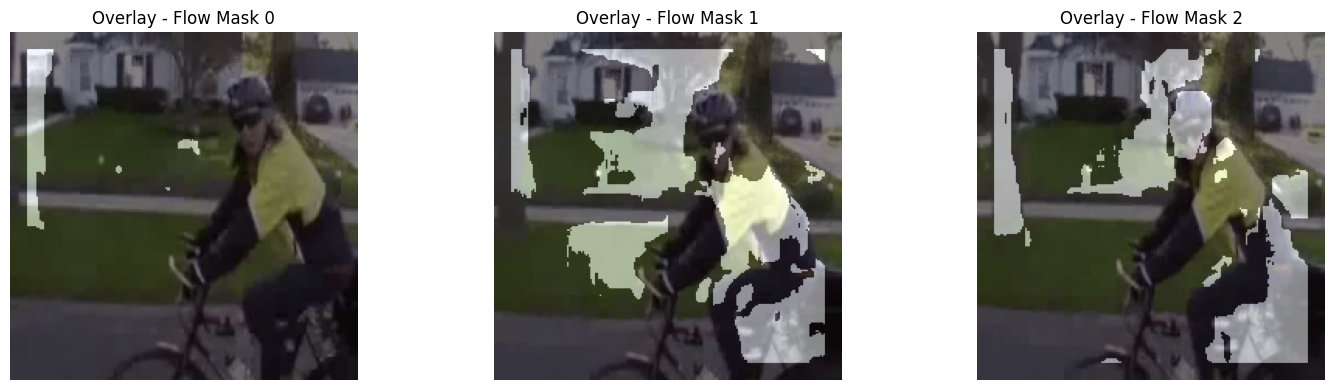

In [15]:

pt_dir = "ucfrep_intermediate_dataset"
selected_video = "v_Biking_g04_c03" 

video_path = os.path.join(pt_dir, selected_video)
flow_path = os.path.join(video_path, "flow.pt")

if not os.path.isdir(video_path):
    raise FileNotFoundError(f"Video folder not found: {video_path}")
if not os.path.isfile(flow_path):
    raise FileNotFoundError(f"flow.pt not found: {flow_path}")

flow = torch.load(flow_path, map_location="cpu")  #(3, 2, 224, 224) ; as the .pt file is laoded with 3 frames
print(f"Loaded flow: {flow.shape} from {flow_path}")

# Choose 3 consecutive frames for flow-mask computation
start_frame = 0  # change this if you want a different chunk
if flow.shape[0] < 3:
    raise ValueError("Not enough frames in flow.pt (need at least 3)")

frame_chunk_indices = [start_frame, start_frame + 1, start_frame + 2]
flow_chunk = flow[frame_chunk_indices].unsqueeze(0)  # (1, 3, 2, 224, 224)

#get flow mask
flow_mask = get_robust_mask(flow_chunk)  # (1, 3, 1, 224, 224)
print(f"Flow mask shape: {flow_mask.shape}")
print(f"Flow mask value range: [{flow_mask.min():.2f}, {flow_mask.max():.2f}]")

# # Visualize
# fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# for i, frame_idx in enumerate(frame_chunk_indices):
#     mask = flow_mask[0, i, 0].numpy()
#     axes[i].imshow(mask, cmap="hot")
#     axes[i].set_title(f"Flow Mask - Frame {frame_idx}")
#     axes[i].axis("off")

# plt.tight_layout()
# plt.show()

# print("\nFlow mask statistics:")
# for i, frame_idx in enumerate(frame_chunk_indices):
#     mask = flow_mask[0, i, 0].numpy()
#     print(f"  Frame {frame_idx}: min={mask.min():.3f}, max={mask.max():.3f}, mean={mask.mean():.3f}, active_pixels={np.count_nonzero(mask)}")


#for overlay
mp4_dir = "UCF_Rep/train"
mp4_path = os.path.join(mp4_dir, selected_video + ".mp4")

if not os.path.isfile(mp4_path):
    raise FileNotFoundError(f"MP4 not found: {mp4_path}")

# Flow was computed on stride=2 frames in preprocessing
# So flow frame i corresponds to raw frame i*2
raw_frame_indices = [i * 2 for i in frame_chunk_indices]

frames = []
cap = cv2.VideoCapture(mp4_path)
for idx in raw_frame_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if not ret:
        raise RuntimeError(f"Failed to read frame {idx} from {mp4_path}")
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = cv2.resize(frame, (224, 224))
    frames.append(frame)
cap.release()

# Overlay masks
alpha = 0.5
cmap = plt.get_cmap("hot")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, frame_idx in enumerate(frame_chunk_indices):
    img = frames[i].astype(np.float32) / 255.0
    mask = flow_mask[0, i, 0].numpy()
    mask_norm = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
    heat = cmap(mask_norm)[..., :3]  # RGB heatmap

    overlay = (1 - alpha) * img + alpha * heat
    overlay = np.clip(overlay, 0, 1)

    axes[i].imshow(overlay)
    axes[i].set_title(f"Overlay - Flow Mask {frame_idx}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [10]:
%pwd
# %cd DiffTrack

'/data/pbk5339/thesis/DiffTrack'